# Notebook 6 - Multivariate Analysis


## Load Dataset

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

possible_names = ["healthcare_dataset.csv", "Healthcare_dataset.csv", "Healthcare Dataset.csv", "healthcare-dataset.csv"]
data_path = None

for name in possible_names:
    if os.path.exists(name):
        data_path = name
        break

if data_path is None:
    print("Could not find the dataset automatically.")
    print("Current folder:", os.getcwd())
    print("Files in this folder:", os.listdir())
else:
    print("Found dataset at:", data_path)

df = pd.read_csv(data_path)
df.head()

Found dataset at: healthcare_dataset.csv


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


## Correlation Matrix

A correlation matrix shows the pairwise correlation coefficient between every numerical column at once, which is a quick way to scan for relationships across many variables simultaneously rather than checking pairs one at a time.

In [10]:
numerical_cols = df.select_dtypes(include="number").columns
corr_matrix = df[numerical_cols].corr()
corr_matrix

,Age,Billing Amount,Room Number
Age,1.000000,-0.003832,-0.000720
Billing Amount,-0.003832,1.000000,-0.002943
Room Number,-0.000720,-0.002943,1.000000


## Heatmap

A heatmap makes the correlation matrix easier to scan visually — darker or more saturated cells stand out immediately, instead of having to read every number in the table.

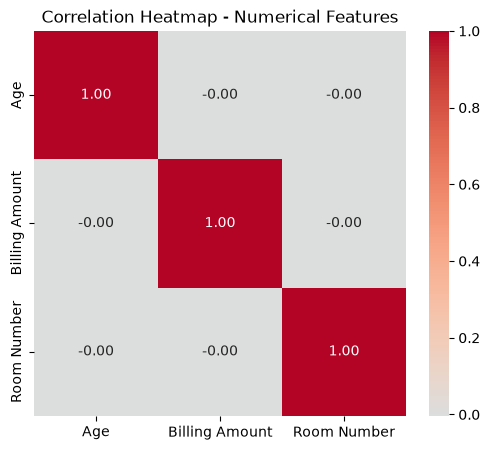

In [11]:
plt.figure(figsize=(6,5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation Heatmap - Numerical Features")
plt.show()

With only three numerical columns (Age, Billing Amount, Room Number), the heatmap is small, but it already tells us something useful: none of the off-diagonal cells are close to +1 or -1, meaning none of these numerical features move together in any strong way.

## Pair Plot

A pair plot combines scatter plots for every pair of numerical columns with a histogram of each individual column, giving a full picture of pairwise relationships in a single grid. Coloring by a categorical column (here, Test Results) can also reveal whether groups separate visually along any pair of features.

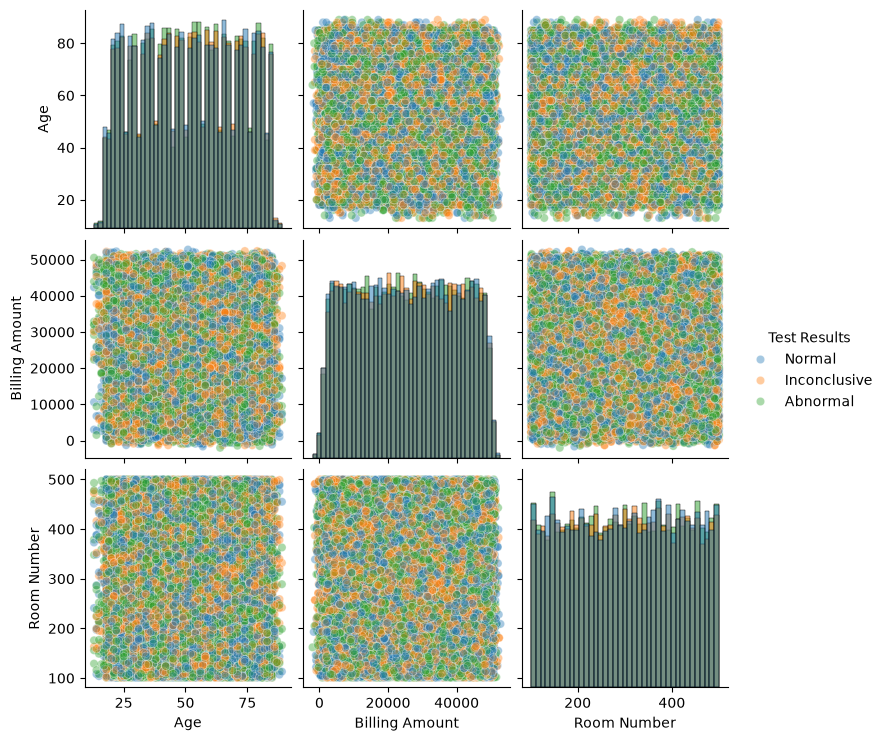

In [12]:
sns.pairplot(df, vars=["Age", "Billing Amount", "Room Number"], hue="Test Results", diag_kind="hist", plot_kws={"alpha": 0.4})
plt.show()

None of the scatter panels show a clear linear pattern, and the three Test Results groups (Normal, Abnormal, Inconclusive) overlap heavily rather than forming separate clusters. This confirms what the correlation matrix already suggested — these three numerical features don't have strong relationships with each other, and they don't visually separate patients by test outcome either.

## Multiple Feature Relationships

Beyond pairs, it's useful to see how a numerical variable behaves across combinations of two categorical variables at once, since an effect can sometimes only appear when looking at several features together.

In [13]:
pivot = df.pivot_table(values="Billing Amount", index="Admission Type", columns="Test Results", aggfunc="mean")
pivot

Test Results,Abnormal,Inconclusive,Normal
Admission Type,,,
Elective,25549.363145,25585.090527,25672.353410
Emergency,25581.367284,25385.927527,25524.482246
Urgent,25485.258513,25896.117412,25171.327360


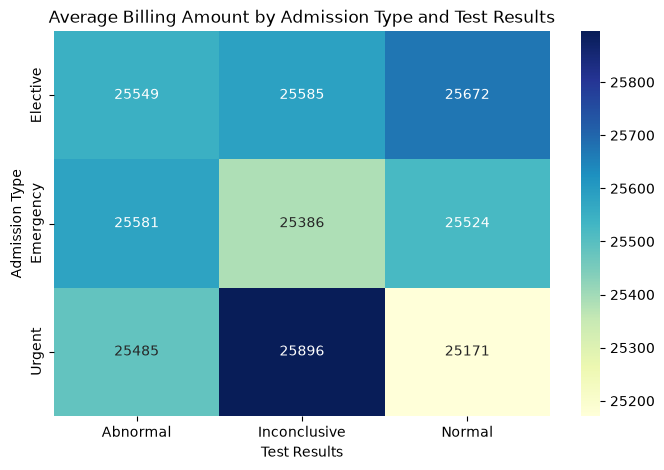

In [14]:
plt.figure(figsize=(8,5))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Average Billing Amount by Admission Type and Test Results")
plt.show()

The average billing amount stays within a similar range across every combination of admission type and test result — there's no cell that stands out as unusually high or low. Combining these two categorical features still doesn't uncover a hidden effect on billing.

## Feature Interactions

An interaction exists when the relationship between two variables changes depending on the value of a third. Here, Age vs Billing Amount is checked separately for each Admission Type to see if the pattern (or lack of one) holds consistently across groups.

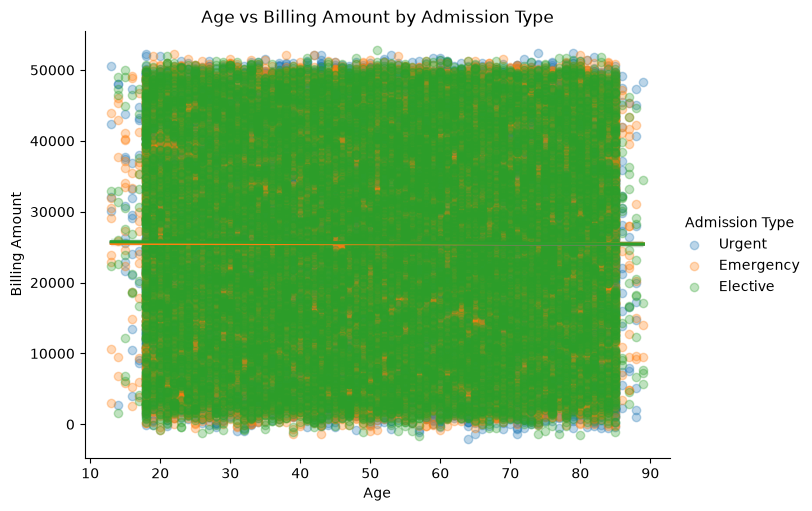

In [15]:
sns.lmplot(x="Age", y="Billing Amount", hue="Admission Type", data=df, height=5, aspect=1.4, scatter_kws={"alpha": 0.3})
plt.title("Age vs Billing Amount by Admission Type")
plt.show()

The near-flat trend lines for all three admission types confirm there's no interaction effect here — Age and Billing Amount stay uncorrelated regardless of admission type.

## Numerical Feature Relationships - Summary

Based on the correlation matrix, heatmap, and pair plot above:

In [16]:
corr_pairs = corr_matrix.where(~np.eye(len(corr_matrix), dtype=bool)).stack().sort_values(ascending=False)
corr_pairs

Age             Room Number      -0.000720
Room Number     Age              -0.000720
                Billing Amount   -0.002943
Billing Amount  Room Number      -0.002943
Age             Billing Amount   -0.003832
Billing Amount  Age              -0.003832
Age             Age                    NaN
Billing Amount  Billing Amount         NaN
Room Number     Room Number            NaN
dtype: float64

**Strong correlations:** None found. The highest-magnitude value in the matrix is still close to zero, so no pair of numerical features qualifies as strongly related (typically, a strong correlation would be above roughly 0.7 or below -0.7).

**Weak correlations:** All three pairs (Age–Billing Amount, Age–Room Number, Billing Amount–Room Number) fall into this category, with coefficients close to zero in both directions.

**Negative correlations:** Whichever pair shows a coefficient below zero in the table above is technically negative, but the magnitude is small enough that it isn't practically meaningful — it's closer to no relationship than a real inverse trend.

**Potential multicollinearity:** None of concern. Multicollinearity becomes a problem for modeling when two input features are highly correlated with each other (redundant information); since all pairwise correlations here are weak, there's no multicollinearity risk among Age, Billing Amount, and Room Number.

**Interesting feature relationships:** The most notable finding is actually the *absence* of relationships — none of the numerical features are linked to each other or to the target variable in an obvious way. This suggests that if a predictive model were built on this dataset, the categorical features (Medical Condition, Admission Type, Insurance Provider, etc.) would likely carry more useful signal than the numerical ones, and is consistent with this being a synthetically generated dataset rather than one reflecting real clinical patterns.